In [2]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb
import preliz as pz

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='pytensor')

In [21]:
SEED = 12

In [22]:
pizza = pd.read_csv('../data/pizza_sales.csv', index_col=0)

In [23]:
pizza = pizza.head(500).copy()

In [24]:
pizza.head()

,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
order_details_id,,,,,,,,,,,
1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [25]:
pizza['order_time'] = pd.to_datetime(pizza['order_time'], format='%H:%M:%S')

In [26]:
pizza['order_time_continuous'] = (
    pizza['order_time'].dt.hour +
    pizza['order_time'].dt.minute / 60 +
    pizza['order_time'].dt.second / 3600
)

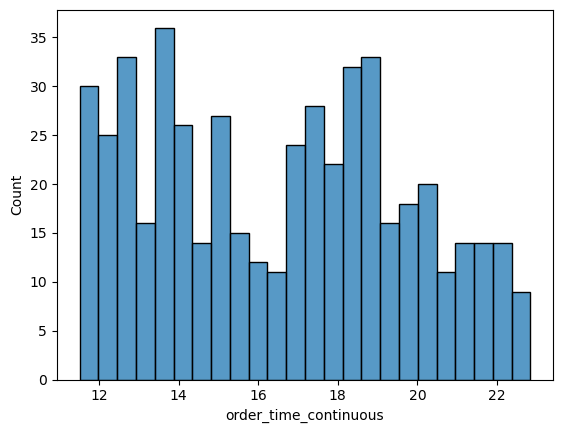

In [27]:
sns.histplot(pizza['order_time_continuous'], bins=24);

1. Plantear un modelo de mezcla finita (por ejemplo, mezcla de dos o m ́as normales)
y justificar la elecci ́on.

In [28]:
obs = pizza['order_time_continuous']

deberia ser poisson

In [81]:
# k = 2

# with pm.Model() as model_poisson:
#     w = pm.Dirichlet('w', a=np.ones(k))

#     λ_1 = pm.Exponential('λ_1', lam=1)   ### TODO: Probar con parametrizacion diferente, con mu
#     λ_2 = pm.Exponential('λ_2', lam=1)

#     components = [
#         pm.Poisson.dist(mu=λ_1),
#         pm.Poisson.dist(mu=λ_2),
#     ]

#     components = pm.Poisson.dist(mu=pm.math.stack([λ_1, λ_2]), shape=(k,))

#     x = pm.Mixture('x', w=w, comp_dists=components, observed=obs)
#     idata_poisson = pm.sample(target_accept=0.9, random_seed=SEED)

In [53]:
k = 2

with pm.Model() as model:
        w = pm.Dirichlet('w', a=np.ones(k))
        μ = pm.Normal('μ', mu=13, sigma=5, shape=k)
        σ = pm.HalfNormal('σ', sigma=5)

        x = pm.NormalMixture('x', w=w, mu=μ, sigma=σ, observed=obs)

        idata = pm.sample(random_seed=SEED, idata_kwargs={"log_likelihood":True}) 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 43 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


2. Analizar la identificabilidad del modelo y discutir posibles problemas de simetr ́ıa
entre componentes.


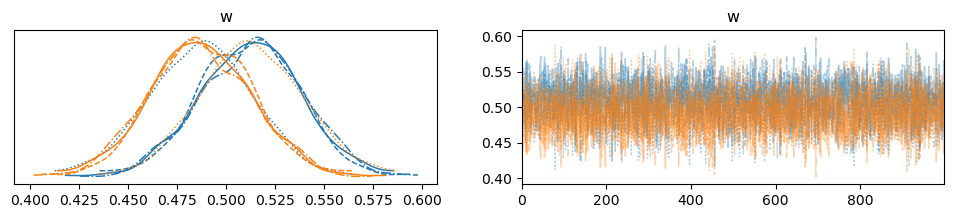

In [55]:
az.plot_trace(idata, var_names=['w']);

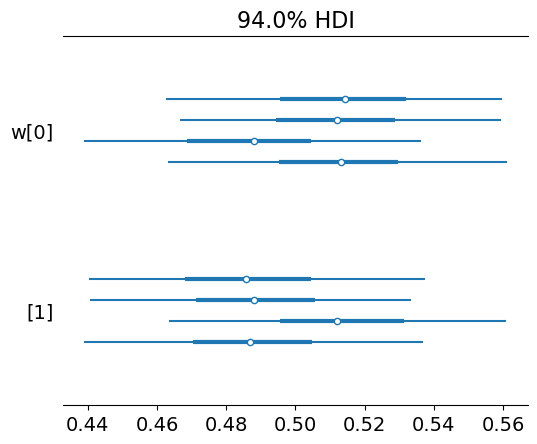

In [56]:
az.plot_forest(idata, var_names=['w']);

Para solucionar hay 2 opciones:
1. usar priors más informativos (es lo que hacemos)
2. ordenar

In [59]:
k = 2

with pm.Model() as model:
        w = pm.Dirichlet('w', a=np.ones(k))
        μ = pm.Normal('μ', mu=[18, 13], sigma=5, shape=k)
        σ = pm.HalfNormal('σ', sigma=5)

        x = pm.NormalMixture('x', w=w, mu=μ, sigma=σ, observed=obs)

        idata = pm.sample(random_seed=SEED, idata_kwargs={"log_likelihood":True}) 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 43 seconds.


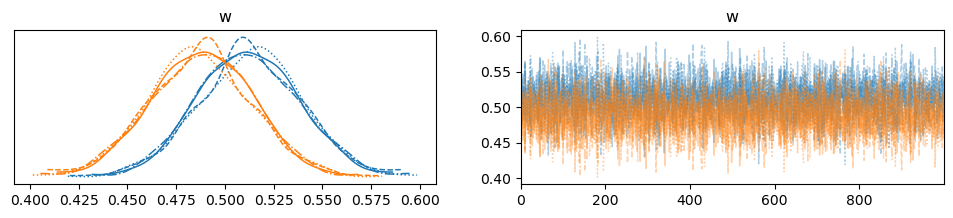

In [62]:
az.plot_trace(idata, var_names=['w']);

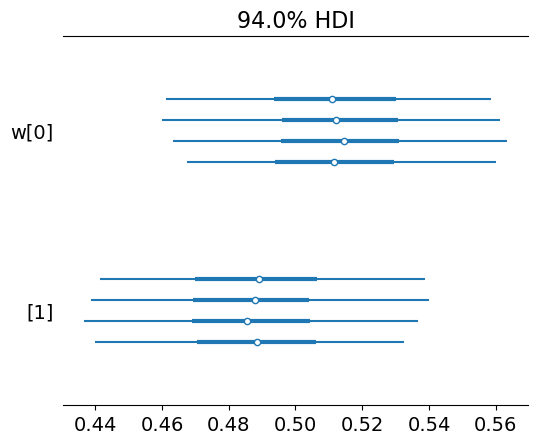

In [61]:
az.plot_forest(idata, var_names=['w']);

In [64]:
az.summary(idata, kind='diagnostics')

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[0],0.002,0.002,4273.0,3382.0,1.0
μ[1],0.002,0.002,3364.0,2901.0,1.0
w[0],0.000,0.000,3706.0,3208.0,1.0
w[1],0.000,0.000,3706.0,3208.0,1.0
σ,0.001,0.001,4795.0,3336.0,1.0


3. Comparar distintos valores de K(n ́umero de componentes) y evaluar cu ́al describe
mejor los datos.

In [80]:
Ks = [2, 3, 4]

idatas = []
modelos = []

for k in Ks:
    with pm.Model() as modelo:
            w = pm.Dirichlet('w', a=np.ones(k))
            μ = pm.Normal('μ', mu=np.quantile(obs, np.linspace(0.1, 0.9, k)), sigma=5, shape=k, transform=pm.distributions.transforms.ordered)
            σ = pm.HalfNormal('σ', sigma=5)

            x = pm.NormalMixture('x', w=w, mu=μ, sigma=σ, observed=obs)

            idata = pm.sample(random_seed=SEED, idata_kwargs={"log_likelihood":True}) 
            idatas.append(idata)
            modelos.append(modelo)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 45 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 75 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 98 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 138 seconds.
There were 194 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [86]:
df_comp = az.compare({f'k={k}': idata for k, idata in zip(Ks, idatas)})
df_comp

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
k=5,0,-1218.748680,8.441629,0.000000,1.0,8.276748,0.000000,False,log
k=4,1,-1218.916291,7.656683,0.167611,0.0,8.389949,0.470210,False,log
k=3,2,-1229.430595,5.505862,10.681914,0.0,8.838281,3.938516,False,log
k=2,3,-1244.516361,3.798961,25.767681,0.0,9.386774,6.107149,False,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

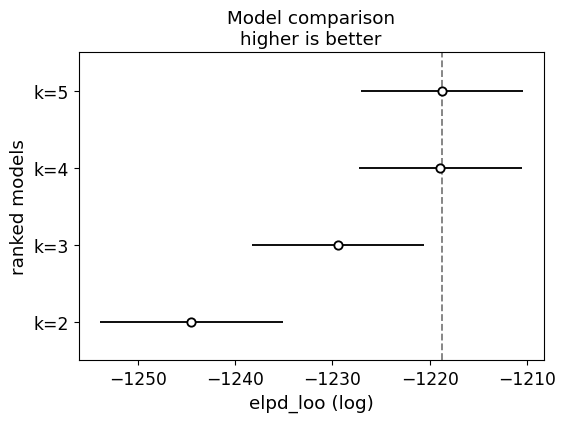

In [87]:
az.plot_compare(df_comp)

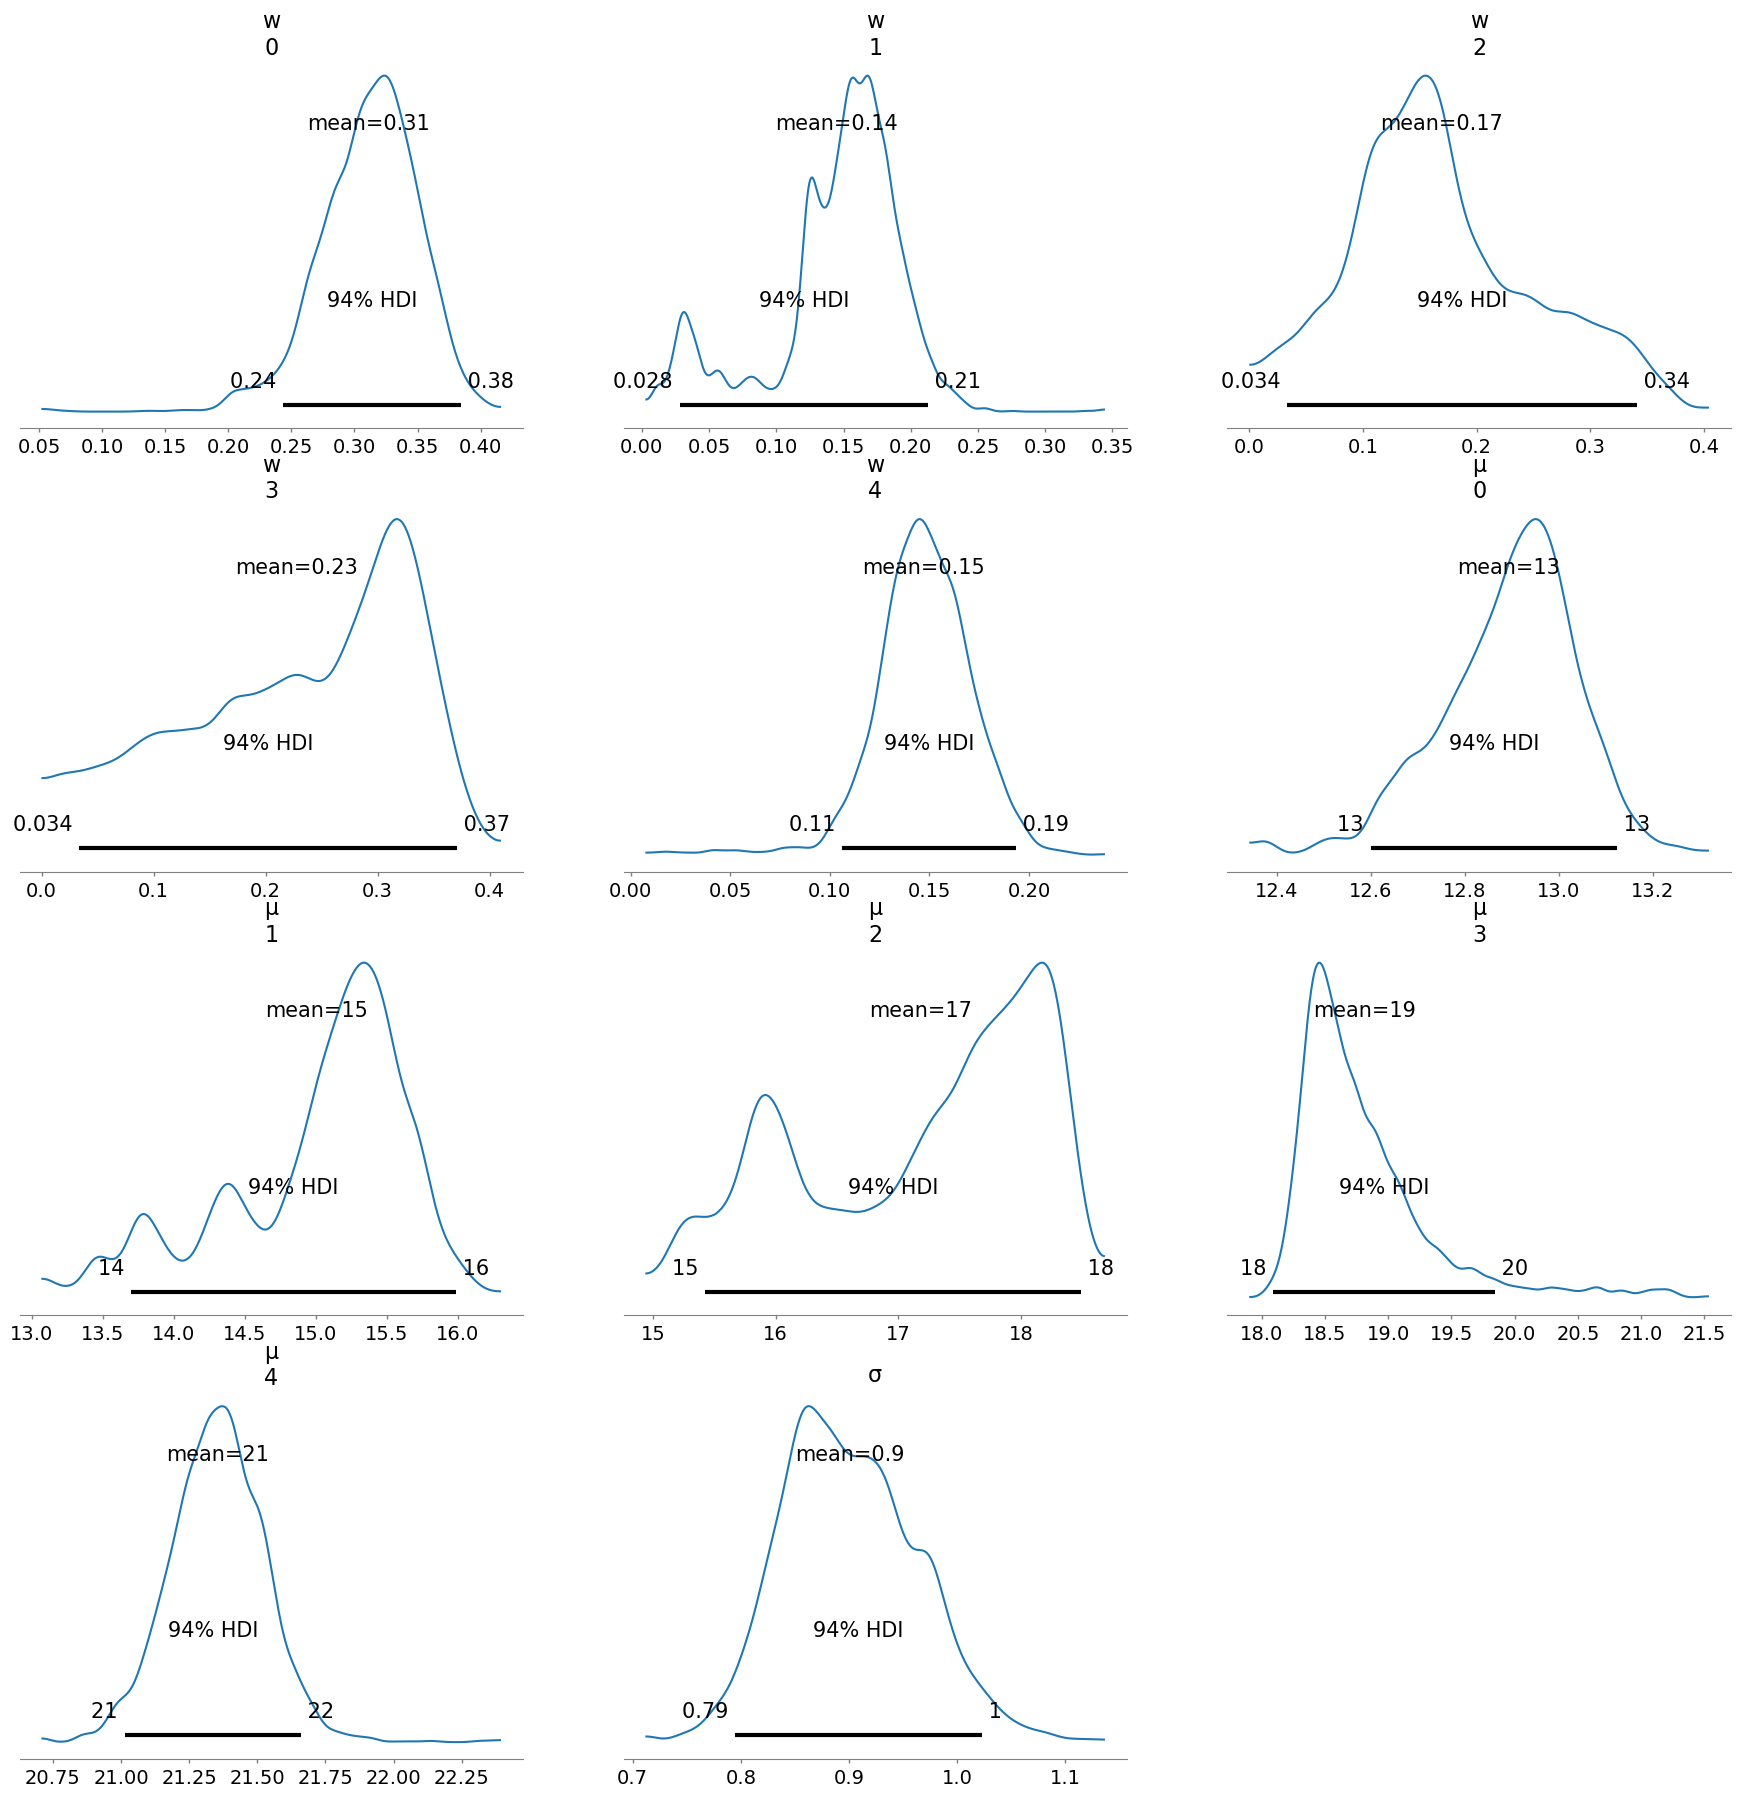

In [89]:
az.plot_posterior(idatas[3]);